In [5]:
csv_text = """quarter_label,fy,quarter_num,period_end,revenue_inr_cr,net_profit_inr_cr,eps_inr,consensus_eps_inr,shares_out_cr
FY24-Q1,2024,1,2023-06-30,36500,6150,14.7,14.2,418
FY24-Q2,2024,2,2023-09-30,37250,6285,15.1,14.9,418
FY24-Q3,2024,3,2023-12-31,38100,6410,15.4,15.2,418
FY24-Q4,2024,4,2024-03-31,38950,6575,15.8,15.5,418
FY25-Q1,2025,1,2024-06-30,40100,6720,16.1,16.0,418
FY25-Q2,2025,2,2024-09-30,41050,6850,16.6,16.3,418
FY25-Q3,2025,3,2024-12-31,42200,7085,17.1,16.8,418
FY25-Q4,2025,4,2025-03-31,43500,7350,17.8,17.2,418
"""
open("quarterly_financials.csv","w").write(csv_text)
print("Saved quarterly_financials.csv")

Saved quarterly_financials.csv


In [6]:
import sqlite3, pandas as pd, matplotlib.pyplot as plt, numpy as np
df = pd.read_csv("quarterly_financials.csv", parse_dates=["period_end"])
df.sort_values("period_end", inplace=True)

In [7]:
conn = sqlite3.connect(":memory:")
df.to_sql("quarters", conn, index=False, if_exists="replace")

sql = """
SELECT quarter_label, fy, quarter_num, period_end, revenue_inr_cr,
       net_profit_inr_cr, eps_inr, consensus_eps_inr, shares_out_cr
FROM quarters ORDER BY period_end
"""
q = pd.read_sql_query(sql, conn, parse_dates=["period_end"])

In [8]:
q["revenue_qoq_%"] = q["revenue_inr_cr"].pct_change(1)*100
q["profit_qoq_%"]  = q["net_profit_inr_cr"].pct_change(1)*100
q["revenue_yoy_%"] = q["revenue_inr_cr"].pct_change(4)*100
q["profit_yoy_%"]  = q["net_profit_inr_cr"].pct_change(4)*100
q["net_margin_%"]  = q["net_profit_inr_cr"]/q["revenue_inr_cr"]*100
q["eps_surprise_%"]= (q["eps_inr"]-q["consensus_eps_inr"])/q["consensus_eps_inr"]*100

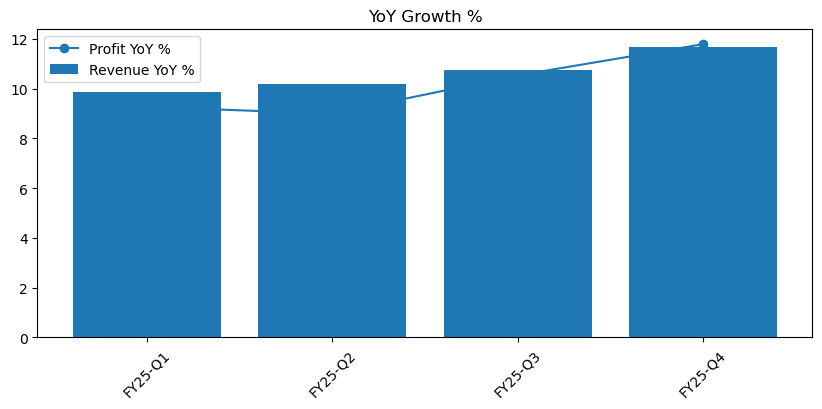

In [9]:
plt.figure(figsize=(10,4))
plt.bar(q["quarter_label"], q["revenue_yoy_%"], label="Revenue YoY %")
plt.plot(q["quarter_label"], q["profit_yoy_%"], marker="o", label="Profit YoY %")
plt.legend(); plt.title("YoY Growth %"); plt.xticks(rotation=45)
plt.show()

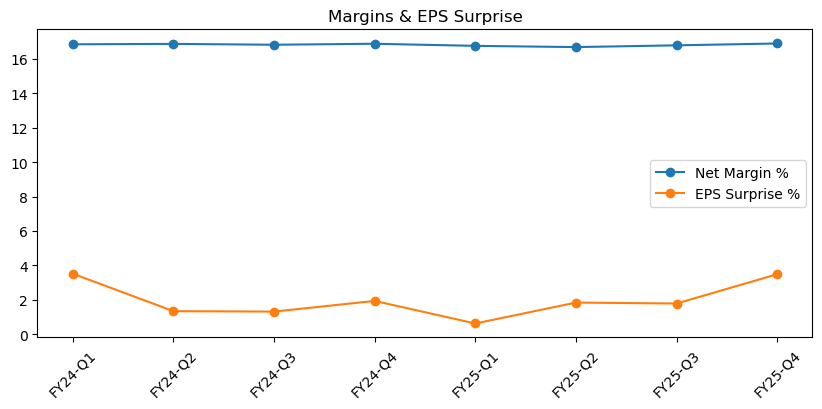

In [10]:
plt.figure(figsize=(10,4))
plt.plot(q["quarter_label"], q["net_margin_%"], marker="o", label="Net Margin %")
plt.plot(q["quarter_label"], q["eps_surprise_%"], marker="o", label="EPS Surprise %")
plt.legend(); plt.title("Margins & EPS Surprise"); plt.xticks(rotation=45)
plt.show()

In [11]:
cols = ["quarter_label","period_end","revenue_inr_cr","net_profit_inr_cr",
        "net_margin_%","revenue_qoq_%","profit_qoq_%","revenue_yoy_%",
        "profit_yoy_%","eps_inr","consensus_eps_inr","eps_surprise_%"]
q[cols].to_csv("dashboard_metrics.csv", index=False)
print("✅ Saved dashboard_metrics.csv")

✅ Saved dashboard_metrics.csv
